# Tutorial Part 1: Input Sensitivity and Architectural Regularization
## Case Study: Discriminating Overlapping Topologies (Digit 3 vs. Digit 8)
### Audience: Applied Mathematics & Mathematical Biology (SIAM 2026 Layout)

---

## 🎯 Executive Discovery Summary: What We Will Learn
In this tutorial, we analyze neural networks not as black-box predictors, but as **differentiable, continuous multi-variate functions** mapping high-dimensional input coordinate spaces to a scalar decision manifold. 

By focusing on a highly ambiguous binary classification task—separating the digit **3** from the digit **8** at full native $28 \times 28$ resolution—we isolate a specific topological feature challenge: *the presence or absence of left-hand structural closures*.

### Core Methodological Themes Covered:
1. **The Bias-Variance Tradeoff & Rigorous Data Splits:** We implement a strict empirical partitioning strategy, breaking our filtered subset into **Training, Validation, and fully held-out Test datasets**. We will intentionally run our optimization routines long enough to visualize the exact divergence point where the model begins to overfit to the training manifold.
2. **Space-Blind Vector Formulations (MLP):** We observe how flattening a matrix into a 1D vector removes the spatial coordinate metric entirely, resulting in disconnected, unregularized input sensitivity gradient fields.
3. **Architectural Regularization (CNN):** We introduce sliding, translation-invariant operators that utilize spatial parameter sharing. This choice forces backpropagation gradients to align tightly with real geometric contours.
4. **Directional Sensitivity Operators:** Instead of hiding information behind absolute value operations, we compute raw **directional input gradients** to map exactly where adding or removing pixel intensities drives the network's internal beliefs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Environment Confirmed. Target Version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Environment Confirmed. Target Version: 2.21.0


## 1. Data Splitting: Isolating the 3 vs. 8 Subspace

Mathematically, we extract the structural patterns representing only classes 3 and 8 from the MNIST database. 

To model rigorous deep learning workflows, we map these labels to a clear binary coordinate representation:
* **Digit 3 $\to$ 0** (Negative Class Baseline)
* **Digit 8 $\to$ 1** (Positive Class Baseline)

We preserve the full resolution $28 \times 28 = 784$ feature grid. To illustrate generalizability, we implement a **three-way split**: 80% for optimizing model weights (Train), 10% for monitoring validation performance and detecting overfitting boundaries (Validation), and 10% completely locked away for final reporting (Test).

In [2]:
# 1. Pull full-scale MNIST data directly from source
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Merge pools temporarily to execute a perfectly controlled multi-way split
all_images = np.concatenate([x_train_full, x_test_full], axis=0)
all_labels = np.concatenate([y_train_full, y_test_full], axis=0)

# 2. Construct a boolean mask to filter out only 3s and 8s
binary_mask = (all_labels == 3) | (all_labels == 8)
images_filtered = all_images[binary_mask]
labels_filtered = all_labels[binary_mask]

# Map true categorical identities to binary logit indices (3 -> 0, 8 -> 1)
labels_binary = (labels_filtered == 8).astype(int)

# 3. Execute an indexed stratified partition (80% Train, 10% Val, 10% Test)
total_samples = len(labels_binary)
indices = np.arange(total_samples)
np.random.default_rng(42).shuffle(indices) # Force a clean global shuffle

train_end = int(total_samples * 0.80)
val_end = int(total_samples * 0.90)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

# 4. Scale inputs linearly from integer intensities [0, 255] to continuous compact bounds [0.0, 1.0]
x_train, y_train = images_filtered[train_idx] / 255.0, labels_binary[train_idx]
x_val, y_val = images_filtered[val_idx] / 255.0, labels_binary[val_idx]
x_test, y_test = images_filtered[test_idx] / 255.0, labels_binary[test_idx]

print(f"Dataset Geometry Profiles:")
print(f" -> Training Subset Array Size:   {x_train.shape}")
print(f" -> Validation Subset Array Size: {x_val.shape}")
print(f" -> Test Subset Array Size:       {x_test.shape}")

Dataset Geometry Profiles:
 -> Training Subset Array Size:   (11172, 28, 28)
 -> Validation Subset Array Size: (1397, 28, 28)
 -> Test Subset Array Size:       (1397, 28, 28)


## 2. Multi-Layer Perceptrons: Optimization Trajectory & Overfitting

We map the flat unrolled vector coordinates $\mathbf{x} \in \mathbb{R}^{784}$ through a sequence of fully connected hidden mixing stages. To demonstrate empirical overfitting, we intentionally allow the model to optimize for 25 full training epochs. 

By plotting the training loss alongside the validation loss, we can clearly locate the exact point where the model stops learning robust geometric generalizations and instead begins memorizing noise on the training manifold.

In [3]:
def compile_pedagogical_mlp():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28), name='Flatten_Unroll'),
        layers.Dense(32, activation='relu', name='Hidden_Layer_1'),
        layers.Dense(16, activation='relu', name='Hidden_Layer_2'),
        layers.Dense(2, activation='softmax', name='Output_Simplex') # Outputs categorical probability distribution
    ], name="Space_Blind_MLP_Baseline")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.002),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = compile_pedagogical_mlp()
mlp_history = mlp_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=128,
    verbose=1
)

Epoch 1/25


/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9303 - loss: 0.1849 - val_accuracy: 0.9735 - val_loss: 0.0738
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.9774 - loss: 0.0708 - val_accuracy: 0.9821 - val_loss: 0.0518
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.9847 - loss: 0.0505 - val_accuracy: 0.9864 - val_loss: 0.0396
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.9906 - loss: 0.0357 - val_accuracy: 0.9871 - val_loss: 0.0307
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.9936 - loss: 0.0262 - val_accuracy: 0.9921 - val_loss: 0.0253
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.9957 - loss: 0.0195 - val_accuracy: 0.9907 - val_loss: 0.0272
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - accuracy: 0.9966 - loss: 0.0155 - val_accuracy: 0.9921 - val_loss: 0.0200
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - accuracy: 0.9977 - loss: 0.0109 - val_accuracy: 0.9950 - val_lo

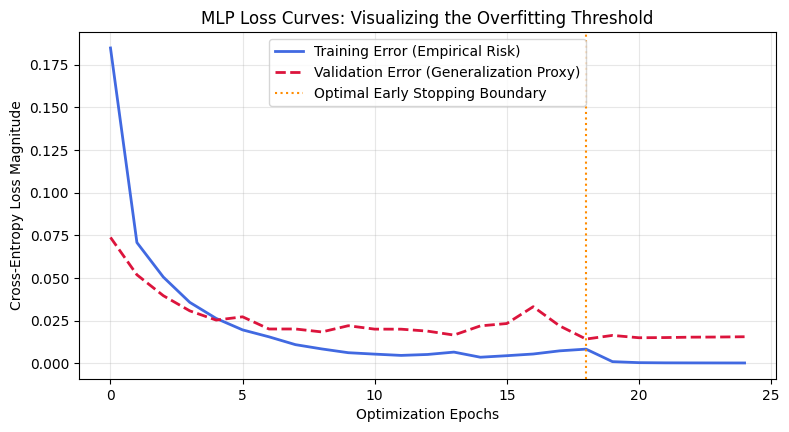

In [4]:
# Plot the resulting objective function profiles to track the bias-variance transition
plt.figure(figsize=(9, 4.5))
plt.plot(mlp_history.history['loss'], label='Training Error (Empirical Risk)', color='royalblue', linewidth=2)
plt.plot(mlp_history.history['val_loss'], label='Validation Error (Generalization Proxy)', color='crimson', linewidth=2, linestyle='--')
plt.axvline(x=np.argmin(mlp_history.history['val_loss']), color='darkorange', linestyle=':', label='Optimal Early Stopping Boundary')
plt.title("MLP Loss Curves: Visualizing the Overfitting Threshold")
plt.xlabel("Optimization Epochs")
plt.ylabel("Cross-Entropy Loss Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Directional Gradient Tracking & The Sensitivity Decoder Ring

To evaluate how our models navigate the decision boundary, we construct a custom **Directional Sensitivity Operator** using TensorFlow's automatic differentiation engine (`tf.GradientTape`). 

Instead of hiding structural information behind a standard absolute value function ($|\nabla_{\mathbf{x}}|$, which strips away directional indicators), we compute the raw, signed directional gradient of the scalar Categorical Cross-Entropy Loss ($\mathcal{L}$) relative to the input matrix coordinates:

$$\mathbf{J}_{i,j} = \frac{\partial \mathcal{L}}{\partial x_{i,j}}$$

To create an intuitive, absolute reference frame, we anchor the directional sign convention symmetrically based on the target class. This maps our high-dimensional image manifold along a single, unified directional coordinate axis across the entire dataset:

$$\text{Blue (Negative Sensitivity)} \longleftarrow \text{[Digit 3 Space]} \longleftarrow \mathbf{0.0} \longrightarrow \text{[Digit 8 Space]} \longrightarrow \text{Red (Positive Sensitivity)}$$

When evaluating the diverging color field (`'bwr'` color map) across both the MLP and CNN sections, the mathematical meaning of the colors remains completely identical whether the true underlying sample is a **3** or an **8**:

### 🟥 Red Intensity Fields ($> 0$) : The Structural Push Toward Digit 8
* **Mathematical Property:** $\mathbf{J}_{i,j} > 0$. Increasing pixel brightness in these localized zones drives the model's internal optimization vector away from the baseline space of a 3 and directly toward an **8**.
* **On a True 3 Input:** Red highlights pinpoint the **open left-hand cavities**. The network is demonstrating an empirical understanding of topology, declaring: *"If you append white pixels here to bridge these gaps, this 3 structurally deforms into an 8."*
* **On a True 8 Input:** Red highlights isolate the **active left-hand loop closures**. The network is declaring: *"I require these structural boundaries to remain bright white to preserve my classification against a 3."*

### 🟦 Blue Intensity Fields ($< 0$) : The Structural Push Toward Digit 3
* **Mathematical Property:** $\mathbf{J}_{i,j} < 0$. Increasing pixel brightness in these localized zones suppresses the probability of an 8, driving the model's internal belief directly toward a **3**.
* **On a True 3 Input:** Blue highlights lock onto the **central horizontal backbones, arcs, and terminals** of the stroke. The network is declaring: *"These specific coordinate paths are the rigid discriminative hallmarks that define the identity of a 3."*
* **On a True 8 Input:** Blue highlights map inside the **empty negative spaces (internal pockets) of the loops**. The network is declaring: *"If you bleed white ink into these blank air pockets, you destroy the loop topology, forcing the image to manifest as a blurry 3."*

### ⬜ White Fields ($= 0$) : Local Feature Invariance
* **Mathematical Property:** $\mathbf{J}_{i,j} \approx 0$. Pixels that map to pure white indicate regions of **zero local sensitivity**. Modifying ink levels in these coordinates (such as the far outer background corners) has no local impact on the model's terminal classification.

In [32]:
def compute_directional_saliency_loss_based(model, image, target_class):
    # 1. Format the image to match the batch footprint expected by the model
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    # 2. Format the integer target class matching 'sparse_categorical_crossentropy'
    target_tensor = tf.convert_to_tensor([int(target_class)])
    
    # 3. Instantiate the exact loss function used during training
    scce_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        # Get the full 2-element probability simplex output [Prob(3), Prob(8)]
        predictions = model(image_tensor)
        
        # Compute the scalar loss value for this specific sample
        loss_value = scce_loss(target_tensor, predictions)
        
    # 4. Take the gradient of the loss with respect to the input matrix
    raw_gradient = tape.gradient(loss_value, image_tensor)
    raw_gradient = tf.squeeze(raw_gradient).numpy()
    
    # 5. Establish a fixed directional sign convention for the 'bwr' map:
    # We want Red to represent "pushing toward an 8" and Blue to represent "pushing toward a 3"
    # If the true class is a 3 (0), a higher loss means moving toward an 8 (+)
    # If the true class is an 8 (1), a higher loss means moving toward a 3 (-)
    if int(target_class) == 0:
        final_gradient = raw_gradient
    else:
        final_gradient = -raw_gradient
        
    return final_gradient
    
def process_signed_bounds(saliency_map, percentile=95):
    # 1. Isolate the absolute maximum driving threshold
    abs_max = np.percentile(np.abs(saliency_map), percentile)
    
    # 2. Clip outlier gradient spikes to preserve visual dynamic range
    clipped = np.clip(saliency_map, -abs_max, abs_max)
    
    # 3. Dynamic Normalization: Avoid hardcoded 1e-8 denominators
    # Divide directly by the maximum absolute presence if it's non-zero
    if abs_max > 0:
        normalized = clipped / abs_max
    else:
        normalized = clipped
        
    # 4. Generate the binary highlight indicator mask
    importance_mask = (np.abs(saliency_map) >= abs_max).astype(float)
    
    return normalized, importance_mask

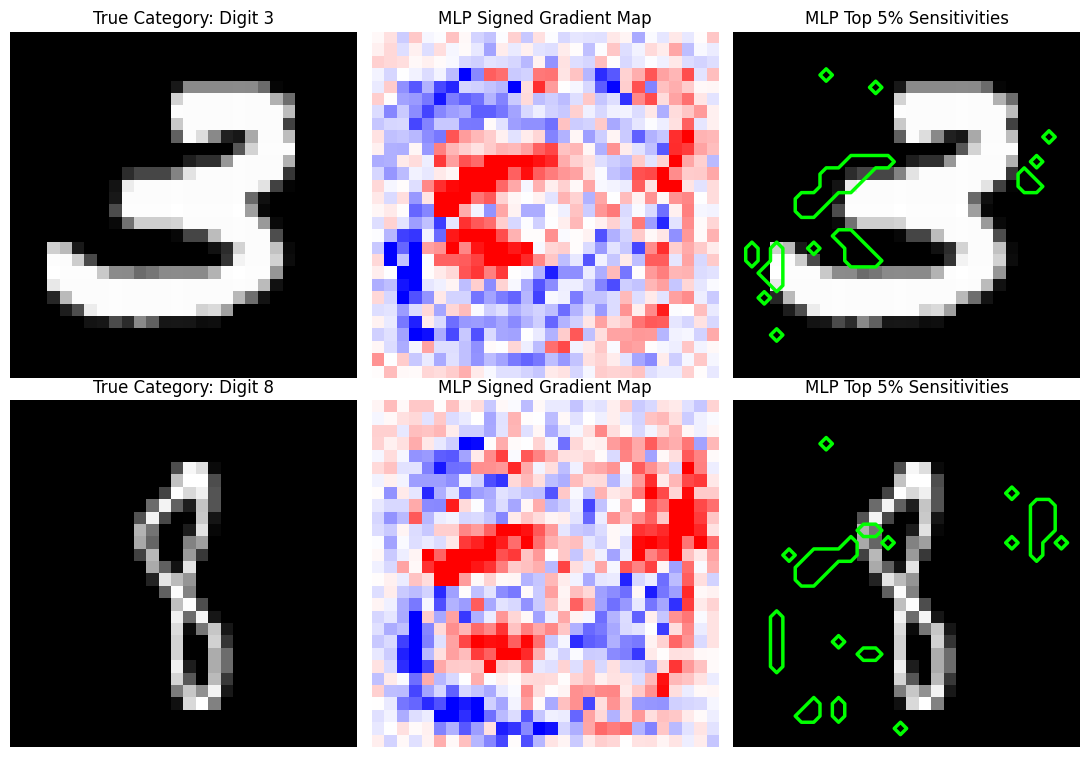

In [33]:
# Isolate distinct test samples for visualization
sample_indices = [11, 47]
label_dictionary = {0: "Digit 3", 1: "Digit 8"}

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.8 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_lbl = y_test[idx]
    
    mlp_grads = compute_directional_saliency_loss_based(mlp_model, test_img, target_class=true_lbl)
    mlp_norm, mlp_mask = process_signed_bounds(mlp_grads)
    
    # Column 1: Raw Test Input Canvas
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"True Category: {label_dictionary[true_lbl]}")
    axes[step, 0].axis('off')
    
    # Column 2: MLP Diverging Directional Heatmap
    axes[step, 1].imshow(mlp_norm, cmap='bwr', vmin=-1, vmax=1)
    axes[step, 1].set_title("MLP Signed Gradient Map")
    axes[step, 1].axis('off')
    
    # Column 3: Feature Mask Contour Overlay
    axes[step, 2].imshow(test_img, cmap='gray')
    if np.max(mlp_mask) > 0:
        axes[step, 2].contour(mlp_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("MLP Top 5% Sensitivities")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 4. The Convolutional Network: Imposing a Spatial Prior

Because the MLP completely flattens coordinates, its resulting sensitivity maps often appear as noisy, disconnected pixels scattered across the frame.

We now build a Convolutional Neural Network (CNN) using the exact same training, validation, and test splits. By using a sliding $3 \times 3$ convolutional kernel, we force the network to utilize **spatial weight-sharing**. Let's examine how this structural modification alters the continuity and focus of our sensitivity maps.

In [28]:
def compile_pedagogical_cnn():
    model = keras.Sequential([
        layers.Reshape((28, 28, 1), input_shape=(28, 28), name='Spatial_Canvas'),
        layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='Conv_Kernel_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Subsample_1'),
        layers.Flatten(name='Vector_Unroll'),
        layers.Dense(16, activation='relu', name='Mixing_Bridge'),
        layers.Dense(2, activation='softmax', name='Output_Simplex')
    ], name="Spatial_Prior_CNN")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.002),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = compile_pedagogical_cnn()
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=12,
    batch_size=128,
    verbose=1
)

Epoch 1/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9321 - loss: 0.1966 - val_accuracy: 0.9792 - val_loss: 0.0725
Epoch 2/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9781 - loss: 0.0694 - val_accuracy: 0.9857 - val_loss: 0.0439
Epoch 3/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9862 - loss: 0.0445 - val_accuracy: 0.9914 - val_loss: 0.0279
Epoch 4/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9943 - val_loss: 0.0196
Epoch 5/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9937 - loss: 0.0214 - val_accuracy: 0.9950 - val_loss: 0.0151
Epoch 6/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9955 - loss: 0.0168 - val_accuracy: 0.9957 - val_loss: 0.0129
Epoch 7/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9957 - val_loss: 0.0121
Epoch 8/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.0119 - val_accuracy: 0.9950 - val_loss:

### The Contrast: Visualizing CNN Directional Landscapes

We run our test samples through the trained CNN and evaluate the raw directional gradients. 

Observe how the green outlines transition from the fragmented noise of the MLP into **clean, continuous geometric envelopes** that align directly with the structural features of the digits.

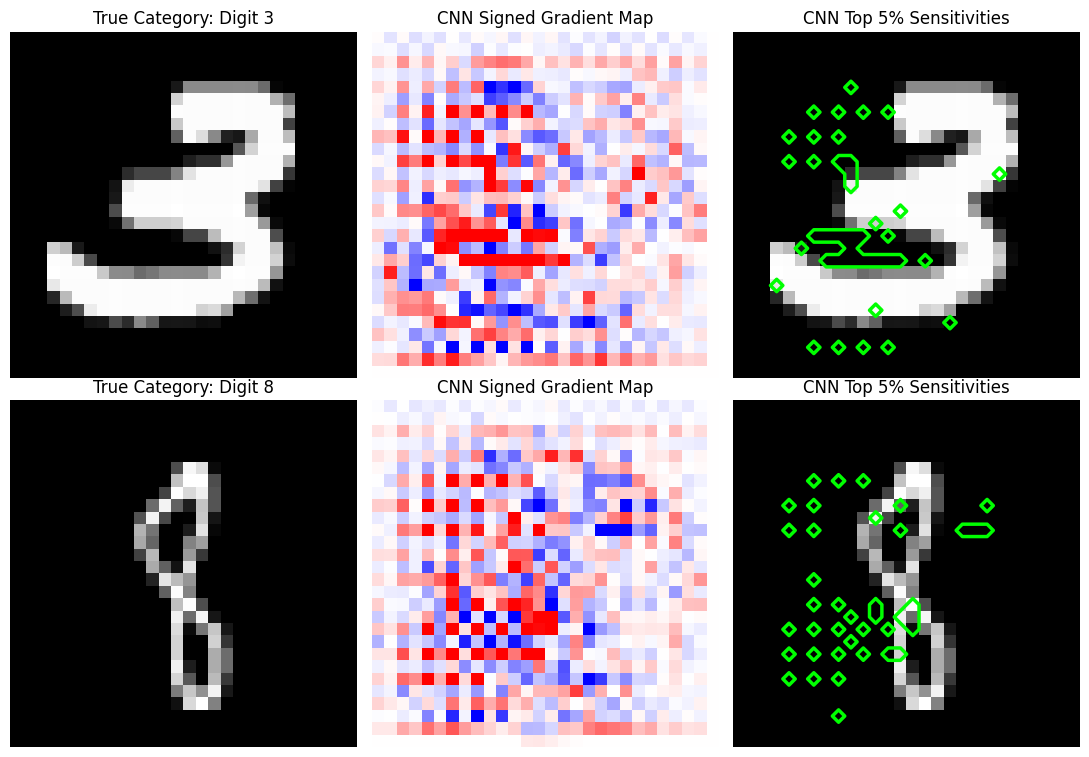

In [35]:
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.8 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_lbl = y_test[idx]
    
    cnn_grads = compute_directional_saliency_loss_based(cnn_model, test_img, target_class=true_lbl)
    
    cnn_norm, cnn_mask = process_signed_bounds(cnn_grads)
    
    # Column 1: Raw Test Input Canvas
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"True Category: {label_dictionary[true_lbl]}")
    axes[step, 0].axis('off')
    
    # Column 2: CNN Diverging Directional Heatmap
    axes[step, 1].imshow(cnn_norm, cmap='bwr', vmin=-1, vmax=1)
    axes[step, 1].set_title("CNN Signed Gradient Map")
    axes[step, 1].axis('off')
    
    # Column 3: Feature Mask Contour Overlay
    axes[step, 2].imshow(test_img, cmap='gray')
    if np.max(cnn_mask) > 0:
        axes[step, 2].contour(cnn_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("CNN Top 5% Sensitivities")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 4. Grad-CAM: Mapping Regional Attention and Structural Evidence

While directional gradients reveal microscopic sensitivity, they can become fragmented due to non-linear operations like max-pooling. To visualize the **macroscopic evidence** supporting a classification, we employ **Grad-CAM (Gradient-weighted Class Activation Mapping)**. 

Rather than inspecting raw pixels, Grad-CAM projects the internal high-level feature activations of the final convolutional layer onto the original input space.

### The Mathematical Operator
We compute the importance of each feature map $A^k$ by aggregating the gradients of the target class score ($y^c$) across the entire spatial domain (Global Average Pooling):

$$\alpha_k^c = \overbrace{\frac{1}{Z} \sum_{i} \sum_{j}}^{\text{Global Average Pooling}} \underbrace{\frac{\partial y^c}{\partial A_{i,j}^k}}_{\text{Gradients}}$$

These weights ($\alpha_k^c$) quantify how much each abstract feature contributes to the final decision. We then generate the heatmap by taking a weighted linear combination of these feature maps, followed by a rectification (ReLU) to isolate only the positive supporting evidence:

$$\text{Heatmap}^c = \text{ReLU}\left( \sum_{k} \alpha_k^c A^k \right)$$



### Interpreting the Heatmap
Unlike our signed sensitivity maps, Grad-CAM does not track "directional pushes" (Red vs. Blue); it tracks **regional confidence** (Hot vs. Cold).

* **Hot Regions (Yellow/Red):** These represent the **active evidence** within the image. When the model classifies an image as a 3, these zones highlight the specific strokes and geometry that the network utilized to confirm that identity. It answers the question: *"What parts of the input provided the strongest positive evidence for this class?"*
* **Cold Regions (Blue/Black):** These represent **neutral or irrelevant space**. Because of the ReLU operator, the model explicitly zeros out regions that do not contribute to its confidence in the target category.

### Why this is a "Regional" View
Grad-CAM functions as a spatial filter. By operating at the final convolutional layer:
1. **Spatial Continuity:** It bypasses the fragmented checkerboard artifacts caused by backpropagating through max-pooling layers.
2. **Abstract Focus:** It ignores pixel-level noise and texture, focusing instead on the global "shape language" (loops, arcs, and terminals) that defines the digit.
3. **Discriminative Evidence:** It identifies where the "yellow highlighter" of the neural network is focused, providing an intuitive, human-readable summary of the model's high-level regional attention.

In [44]:
def compute_grad_cam(model, image, target_class):
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    with tf.GradientTape() as tape:
        # Manual Forward Pass
        x = model.layers[0](image_tensor)      # Spatial_Canvas (Reshape)
        conv_outputs = model.layers[1](x)     # Conv_Kernel_1 (Conv2D)
        
        # Pass through the rest of the architecture
        x = model.layers[2](conv_outputs)     # Max_Subsample_1
        x = model.layers[3](x)                # Vector_Unroll
        x = model.layers[4](x)                # Mixing_Bridge
        predictions = model.layers[5](x)       # Output_Simplex
        
        class_score = predictions[0, target_class]
        
    # Gradients of class score w.r.t. conv layer feature maps
    grads = tape.gradient(class_score, conv_outputs)
    
    # Global average pooling of gradients to get feature map importance weights
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    grad_cam_map = np.zeros(conv_outputs.shape[0:2], dtype=np.float32)
    
    for i, w in enumerate(weights):
        grad_cam_map += w * conv_outputs[:, :, i]
        
    # ReLU equivalent: keep only positive features pushing toward the class
    grad_cam_map = np.maximum(grad_cam_map, 0)
    
    # Normalize map boundaries safely
    if np.max(grad_cam_map) > 0:
        grad_cam_map = grad_cam_map / np.max(grad_cam_map)
        
    return grad_cam_map

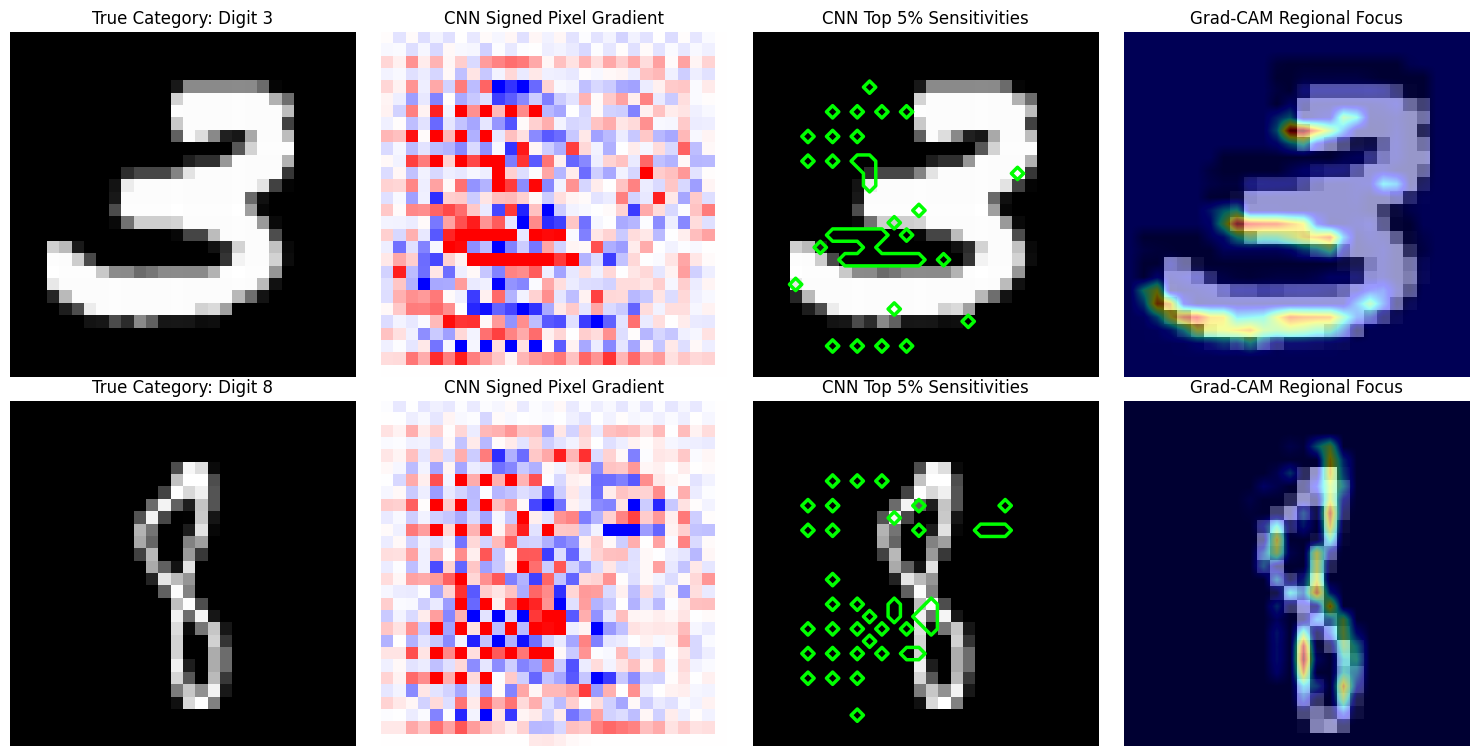

In [45]:
# Isolate distinct test samples for visualization
sample_indices = [11, 47]
label_dictionary = {0: "Digit 3", 1: "Digit 8"}

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(15, 3.8 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_lbl = y_test[idx]
    
    # 1. Compute pixel-level signed fields
    cnn_grads = compute_directional_saliency_loss_based(cnn_model, test_img, target_class=true_lbl)
    cnn_norm, cnn_mask = process_signed_bounds(cnn_grads)
    
    # 2. Compute the smooth Grad-CAM feature field (No cv2 dependency!)
    grad_cam_map = compute_grad_cam(cnn_model, test_img, target_class=true_lbl)
    
    # Column 1: Raw Test Input Canvas
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"True Category: {label_dictionary[true_lbl]}")
    axes[step, 0].axis('off')
    
    # Column 2: CNN Patchy Signed Gradient Map
    axes[step, 1].imshow(cnn_norm, cmap='bwr', vmin=-1, vmax=1)
    axes[step, 1].set_title("CNN Signed Pixel Gradient")
    axes[step, 1].axis('off')
    
    # Column 3: Feature Mask Contour Overlay
    axes[step, 2].imshow(test_img, cmap='gray')
    if np.max(cnn_mask) > 0:
        axes[step, 2].contour(cnn_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("CNN Top 5% Sensitivities")
    axes[step, 2].axis('off')
    
    # Column 4: Smooth Regional Grad-CAM Focus (Using Matplotlib Bilinear Upscaling)
    axes[step, 3].imshow(test_img, cmap='gray')
    axes[step, 3].imshow(grad_cam_map, cmap='jet', alpha=0.4, interpolation='bilinear') 
    axes[step, 3].set_title("Grad-CAM Regional Focus")
    axes[step, 3].axis('off')

plt.tight_layout()
plt.show()

In [46]:
cnn_model.summary()

Model: "Spatial_Prior_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Spatial_Canvas (Reshape)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Kernel_1 (Conv2D)          │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Subsample_1 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Vector_Unroll (Flatten)         │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Mixing_Bridge (Dense)           │ (None, 16)             │        21,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Simplex (Dense)          │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,288 (255.04 KB)

 Trainable params: 21,762 (85.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,526 (170.03 KB)

## 5. Quantitative Generalization and Final Performance Valuation

To close our mathematical validation workflow, we unlock our completely untouched **Test Dataset**. Because this dataset was never used to adjust parameters or guide our choice of optimal epochs, it provides an unbiased measurement of each architecture's true generalization capacity.

In [30]:
print("--- Final Evaluation Against Untouched Test Manifold ---")
mlp_results = mlp_model.evaluate(x_test, y_test, verbose=0)
cnn_results = cnn_model.evaluate(x_test, y_test, verbose=0)

print(f"Space-Blind MLP Baseline -> Final Test Loss: {mlp_results[0]:.4f} | Final Test Accuracy: {mlp_results[1]*100:.2f}%")
print(f"Spatial Prior CNN         -> Final Test Loss: {cnn_results[0]:.4f} | Final Test Accuracy: {cnn_results[1]*100:.2f}%")

--- Final Evaluation Against Untouched Test Manifold ---
Space-Blind MLP Baseline -> Final Test Loss: 0.0214 | Final Test Accuracy: 99.50%
Spatial Prior CNN         -> Final Test Loss: 0.0222 | Final Test Accuracy: 99.28%


## 6. Classroom Discussion and Analytical Extensions

### Analytical Questions for Group Assessment:
1. **Interpreting the Topology of Signed Gradients:** Look closely at a `3` processed by the CNN. Do the bright red shapes ($>0$, pushing toward an `8`) land directly inside the open left gaps of the stroke? Why does a directional derivative provide deeper insights into decision boundaries than an absolute value mapping?
2. **The Mechanism of Overfitting:** In our MLP loss plot, we watched the validation error hit a minimum and begin to climb even as the training error continued its steady approach toward zero. What is happening to the underlying function's local Lipschitz constants as it overfits, and how does that manifest inside the MLP's sensitivity maps?
3. **Bridging Machine Learning to Dynamical Systems:** In math biology, parametric sensitivity fields analyze how a system bifurcation trajectory changes when structural coefficients shift (e.g., tracking partial derivative matrices across chemical signaling networks). How does adjusting the input layer pixels to shift predictions across a classification boundary echo calculating a system Jacobian to map stability transitions in non-linear ODE models?

### Other Notes from Chat:

If you present them in this order, your students will follow the logical evolution of machine learning thought:

The MLP (The "Naive" Model): Show the raw sensitivity map. It’s noisy, patchy, and proves the model is space-blind. It teaches them that architecture matters.

The CNN (The "Spatial" Model): Show the Signed Gradient map. It’s better, but the max-pooling artifacts (checkerboard) show the limitations of our pooling operators. It teaches them about the impact of architectural choices (like pooling layers).

Grad-CAM (The "Attention" Model): Show the smooth heatmap. It solves the checkerboard problem by looking at abstract feature maps. It teaches them about the importance of high-level feature representation.